# Training dataset generation

This code can be used to generate a dataset of airfoils that are optimized for random values of altitudes and velocity

In [13]:
%load_ext autoreload
%autoreload 2

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.airfoil_predictor import AirfoilOptimizer
from src.geometry import AirfoilGeometry
import numpy as np
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## The Bayesian Optimizer

To find the most optimized shape for a given value of altitude and velocity, were using the Bayesian Optimizer from `Optuna`, which is a sampler using TPE *(Tree-structured Parzen Estimator)* algorithm. Here is an example:

Optimizing for V=100m/s at 100m...
Optimization Complete!
Best NACA: 9409
Max L/D: 221.42


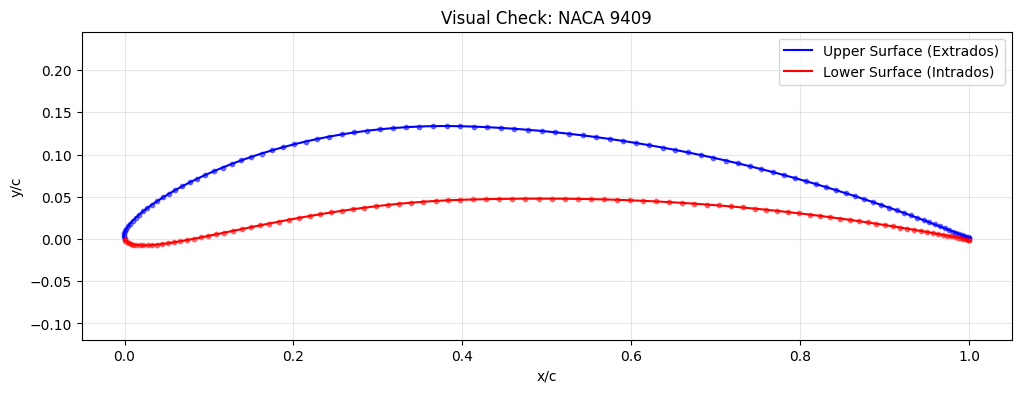

In [14]:
# Initialize the optimizer
optimizer = AirfoilOptimizer(chord=0.5, alpha=5.0)

# Define your target condition
velocity = 100    # m/s
altitude = 100  # meters

print(f"Optimizing for V={velocity}m/s at {altitude}m...")

# Run the optimization
best_params, max_ld = optimizer.find_best_airfoil(velocity, altitude, n_trials=100)

print(f"Optimization Complete!")
print(f"Best NACA: {best_params['m']}{best_params['p']}{best_params['t']:02d}")
print(f"Max L/D: {max_ld:.2f}")

geo = AirfoilGeometry(n_points=100)

geo.plot_naca4(m=best_params['m'], p=best_params['p'], t=best_params['t'])

## Training dataset generation

The dataset is created by generating random values for velocity and altitude, and using the bayesian optimizer to find the most optimized shape

In [15]:
# Configuration
N_POINTS_DATASET = 100
N_TRIALS_PER_OPTI = 200
dataset = []

optimizer = AirfoilOptimizer(chord=1.0, alpha=0.0)

for i in range(N_POINTS_DATASET):
    v_target = np.random.uniform(50, 250)
    alt_target = np.random.uniform(0, 12000)

    best, finesse = optimizer.find_best_airfoil(v_target, alt_target, n_trials=N_TRIALS_PER_OPTI)
    
    dataset.append({
        'velocity': v_target,
        'altitude': alt_target,
        'best_m': best['m'],
        'best_p': best['p'],
        'best_t': int(best['t']),
        'finesse_max': finesse,
        'naca_complet': f"{best['m']}{best['p']}{int(best['t']):02d}"
    })
    
    print(f"✅ Point {i+1}/{N_POINTS_DATASET} | V={v_target:>5.1f}m/s | Alt={alt_target:>5.0f}m -> NACA {dataset[-1]['naca_complet']}")

df_airfoil_ai = pd.DataFrame(dataset)
print("\n Dataset Generation Complete!")
display(df_airfoil_ai.head())

✅ Point 1/100 | V=230.9m/s | Alt= 3112m -> NACA 6503
✅ Point 2/100 | V= 73.1m/s | Alt= 4691m -> NACA 8705
✅ Point 3/100 | V= 59.1m/s | Alt=10305m -> NACA 9602
✅ Point 4/100 | V= 51.2m/s | Alt= 3867m -> NACA 8704
✅ Point 5/100 | V=235.9m/s | Alt= 8201m -> NACA 4502
✅ Point 6/100 | V=205.9m/s | Alt= 7075m -> NACA 7603
✅ Point 7/100 | V=216.3m/s | Alt= 1843m -> NACA 7604
✅ Point 8/100 | V= 81.8m/s | Alt= 9659m -> NACA 8704
✅ Point 9/100 | V=184.9m/s | Alt= 4295m -> NACA 9605
✅ Point 10/100 | V= 55.5m/s | Alt= 5815m -> NACA 8704
✅ Point 11/100 | V= 66.1m/s | Alt= 6429m -> NACA 8704
✅ Point 12/100 | V=114.2m/s | Alt= 2732m -> NACA 9603
✅ Point 13/100 | V=135.7m/s | Alt=11066m -> NACA 8705
✅ Point 14/100 | V=144.3m/s | Alt= 6020m -> NACA 9603
✅ Point 15/100 | V=175.7m/s | Alt= 1362m -> NACA 9605
✅ Point 16/100 | V= 78.8m/s | Alt= 6755m -> NACA 8705
✅ Point 17/100 | V=169.4m/s | Alt= 2158m -> NACA 9605
✅ Point 18/100 | V=221.1m/s | Alt= 7545m -> NACA 5604
✅ Point 19/100 | V=170.2m/s | Alt= 75

,velocity,altitude,best_m,best_p,best_t,finesse_max,naca_complet
0,230.938447,3111.659820,6,5,3,226.983235,6503
1,73.123808,4690.783401,8,7,5,317.669602,8705
2,59.134136,10305.298871,9,6,2,252.365836,9602
3,51.248015,3867.088448,8,7,4,298.786866,8704
4,235.910335,8200.604546,4,5,2,151.682964,4502


The dataset can be saved in the ../data/ folder

In [16]:
dataset_name = "airfoil_optimization_results.csv"
df_airfoil_ai.to_csv("../data/"+dataset_name, index=False)